In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint


In [2]:
DATA_DIR = r'M:\University\University Work\Semestor 5\Ann & DL\LAB\ANN & DL\Data'
CSV_PATH = os.path.join(DATA_DIR, 'Images110.csv')
MODEL_DIR = r'M:\University\University Work\Semestor 5\Ann & DL\LAB\ANN & DL\Model\Our'
os.makedirs(MODEL_DIR, exist_ok=True)

IMG_H, IMG_W, IMG_C = 110, 110, 3
INPUT_DIM = IMG_H * IMG_W * IMG_C   # 36300
EPOCHS = 30
BATCH_SIZE = 32

print("CSV:", CSV_PATH)
print("Model dir:", MODEL_DIR)

CSV: M:\University\University Work\Semestor 5\Ann & DL\LAB\ANN & DL\Data\Images110.csv
Model dir: M:\University\University Work\Semestor 5\Ann & DL\LAB\ANN & DL\Model\Our


In [3]:
if not os.path.exists(CSV_PATH):
    raise FileNotFoundError(f"CSV not found: {CSV_PATH}")

df = pd.read_csv(CSV_PATH)                      # minimal: read entire CSV
labels = df.iloc[:, 0].to_numpy()               # first column = label (kept if you need it)
pixels = df.iloc[:, 1:].to_numpy(dtype=np.float32)

expected = INPUT_DIM
if pixels.shape[1] != expected:
    raise ValueError(f'Expected {expected} pixel columns, found {pixels.shape[1]}')

# normalize and reshape to images
X = pixels.reshape(-1, IMG_H, IMG_W, IMG_C) / 255.0
Y = labels
print("Loaded", X.shape[0], "images ->", X.shape)

Loaded 2483 images -> (2483, 110, 110, 3)


In [4]:
# Flatten images for dense autoencoder (simple / readable)
X_flat = X.reshape(len(X), -1)
X_train, X_val = train_test_split(X_flat, test_size=0.15, random_state=42)
print("Train:", X_train.shape, "Val:", X_val.shape)

Train: (2110, 36300) Val: (373, 36300)


In [5]:
inp = layers.Input(shape=(INPUT_DIM,), name='input_flat')

# encoder
x = layers.Dense(1024, activation='relu')(inp)
x = layers.Dense(256, activation='relu')(x)
latent = layers.Dense(64, activation='relu', name='latent')(x)

# decoder
x = layers.Dense(256, activation='relu')(latent)
x = layers.Dense(1024, activation='relu')(x)
out = layers.Dense(INPUT_DIM, activation='sigmoid')(x)   # output in [0,1]

autoencoder = Model(inp, out, name='dense_autoencoder')
autoencoder.compile(optimizer='adam', loss='mse')        # MSE is appropriate for reconstruction
autoencoder.summary()



Model: "dense_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_flat (InputLayer)         │ (None, 36300)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1024)           │    37,172,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent (Dense)                  │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        16,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1024)           │       263,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 36300)          │    37,207,500 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,938,380 (285.87 MB)

 Trainable params: 74,938,380 (285.87 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1),
    ModelCheckpoint(os.path.join(MODEL_DIR, 'autoencoder_best.keras'),
                    monitor='val_loss', save_best_only=True, verbose=1)
]

history = autoencoder.fit(
    X_train, X_train,
    validation_data=(X_val, X_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 980ms/step - loss: 0.0733
Epoch 1: val_loss improved from None to 0.05752, saving model to M:\University\University Work\Semestor 5\Ann & DL\LAB\ANN & DL\Model\Our\autoencoder_best.keras
66/66 ━━━━━━━━━━━━━━━━━━━━ 75s 1s/step - loss: 0.0659 - val_loss: 0.0575 - learning_rate: 0.0010
Epoch 2/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 975ms/step - loss: 0.0571
Epoch 2: val_loss improved from 0.05752 to 0.05281, saving model to M:\University\University Work\Semestor 5\Ann & DL\LAB\ANN & DL\Model\Our\autoencoder_best.keras
66/66 ━━━━━━━━━━━━━━━━━━━━ 70s 1s/step - loss: 0.0554 - val_loss: 0.0528 - learning_rate: 0.0010
Epoch 3/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 974ms/step - loss: 0.0510
Epoch 3: val_loss improved from 0.05281 to 0.04909, saving model to M:\University\University Work\Semestor 5\Ann & DL\LAB\ANN & DL\Model\Our\autoencoder_best.keras
66/66 ━━━━━━━━━━━━━━━━━━━━ 70s 1s/step - loss: 0.0506 - val_loss: 0.0491 - learning_rate: 0.0010
Epoch 4/30
66/66 ━━

In [7]:
out_path = os.path.join(MODEL_DIR, 'autoencoder_final.keras')
autoencoder.save(out_path)
print("Saved model to", out_path)

Saved model to M:\University\University Work\Semestor 5\Ann & DL\LAB\ANN & DL\Model\Our\autoencoder_final.keras


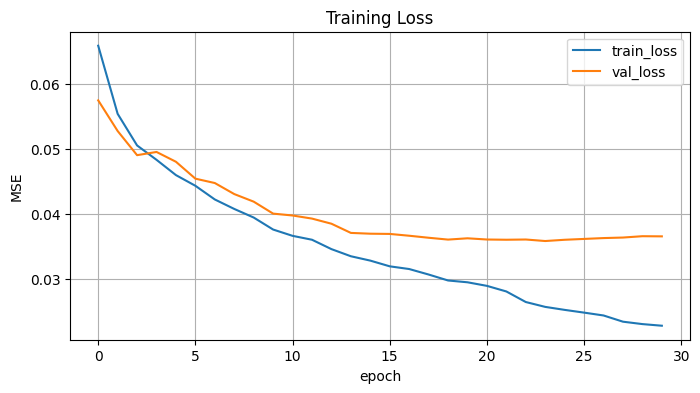

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step


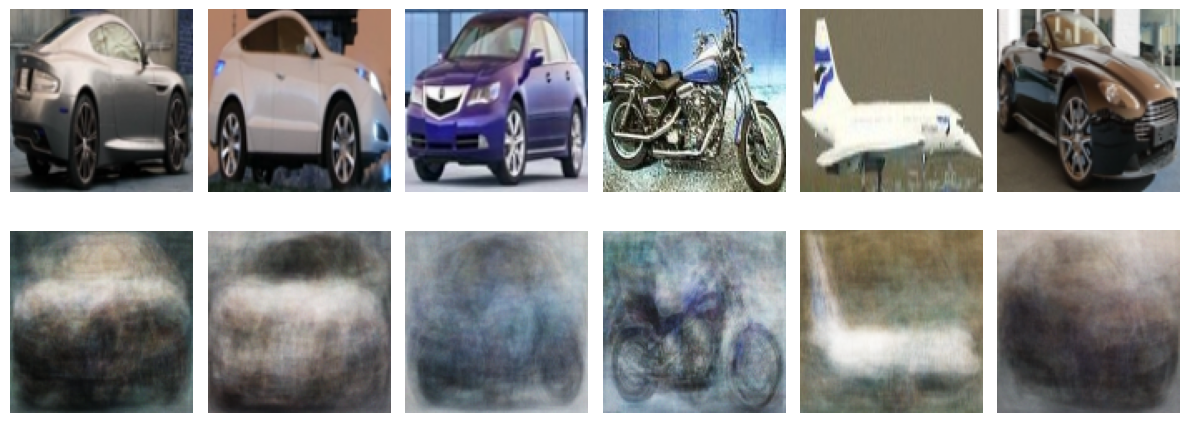

In [8]:
# Plot training history
plt.figure(figsize=(8,4))
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.legend()
plt.title('Training Loss')
plt.xlabel('epoch')
plt.ylabel('MSE')
plt.grid(True)
plt.show()

# Display sample reconstructions
n = min(6, X_val.shape[0])
idx = np.random.choice(len(X_val), n, replace=False)
orig = X_val[idx].reshape(n, IMG_H, IMG_W, IMG_C)
recon_flat = autoencoder.predict(X_val[idx])
recon = recon_flat.reshape(n, IMG_H, IMG_W, IMG_C)

plt.figure(figsize=(12,5))
for i in range(n):
    plt.subplot(2, n, i+1)
    plt.imshow(orig[i])
    plt.axis('off')
    plt.subplot(2, n, n+i+1)
    plt.imshow(recon[i])
    plt.axis('off')
plt.tight_layout()
plt.show()